# APN Dataset EDA Report: HumanActivity

本报告用于深入理解该数据集在 APN 项目中的形态、含义与时序特性。

- 覆盖内容：数据来源、样本规模、不规则采样特性、缺失模式、变量相关性、典型时序轨迹
- 注意：首次运行可能触发自动下载或预处理（取决于数据集）


## 数据集背景

HumanActivity 来自 UCI 的可穿戴传感器活动识别数据。
在 APN 中，数据被整理为 4 个身体位置传感器（每个 3 轴），共 12 通道。
任务本质是对不规则采样的人体活动传感序列进行建模。


In [1]:
import importlib
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
if (PROJECT_ROOT / 'reports').exists() and str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import reports.irregular_eda_utils as _eda
_eda = importlib.reload(_eda)

compute_dataset_summary = _eda.compute_dataset_summary
get_sample_lengths = _eda.get_sample_lengths
plot_channel_correlation = _eda.plot_channel_correlation
plot_channel_missingness = _eda.plot_channel_missingness
plot_interarrival_distribution = _eda.plot_interarrival_distribution
plot_multichannel_trajectories = _eda.plot_multichannel_trajectories
plot_sample_length_distributions = _eda.plot_sample_length_distributions
to_long_frame = _eda.to_long_frame

sns.set_theme(style='whitegrid', context='talk')
np.random.seed(0)


## 1) 加载数据并统一结构

将不同数据集统一为 records = [{t, x}] 形式：
- t: 一维时间戳数组
- x: 二维观测矩阵 [time, channel]


In [2]:
from data.dependencies.HumanActivity.HumanActivity import HumanActivity
from reports.irregular_eda_utils import records_from_human_activity

dataset_name = 'HumanActivity'
time_unit = 'quantized tick (dataset-specific)'
root = PROJECT_ROOT / 'storage' / 'datasets' / 'HumanActivity'
root.mkdir(parents=True, exist_ok=True)

ha = HumanActivity(root=str(root), download=True)
records = records_from_human_activity(ha)

tag_map = ['ANKLE_LEFT', 'ANKLE_RIGHT', 'CHEST', 'BELT']
axes = ['x', 'y', 'z']
channel_names = [f'{tag}_{ax}' for tag in tag_map for ax in axes]
print(f'Loaded {len(records)} records from HumanActivity.')


Loaded 25 records from HumanActivity.


In [3]:
summary = compute_dataset_summary(records, channel_names)
lens = get_sample_lengths(records)
summary


n_samples                  25.00
n_channels                 12.00
mean_timestamps          6593.36
median_timestamps        6267.00
mean_observations       79120.32
median_observations     75204.00
mean_duration          218492.08
dtype: float64

## 2) 样本级统计

观察每个样本时间点数量、总观测数量、时长分布。

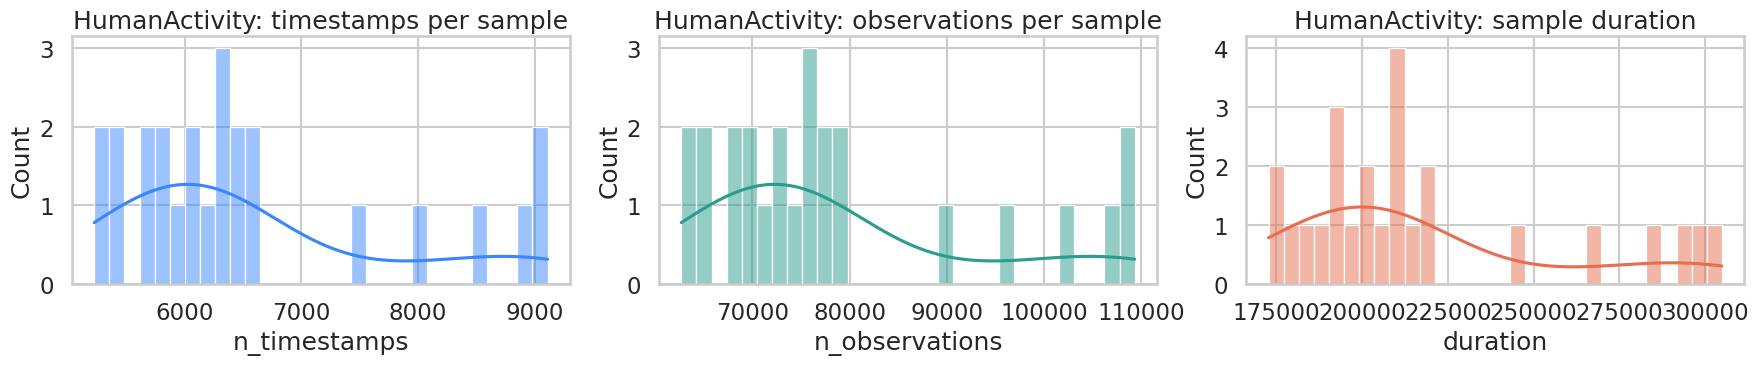

In [4]:
plot_sample_length_distributions(lens, title_prefix=f'{dataset_name}: ')

## 3) 生成长表并查看总体观测规模

In [5]:
long_df = to_long_frame(records, channel_names)
print('long_df shape:', long_df.shape)
long_df.head()


long_df shape: (1978008, 4)


,sample_id,time,channel,value
0,0,0.0,ANKLE_LEFT_x,4.062931
1,0,0.0,ANKLE_LEFT_y,1.892434
2,0,0.0,ANKLE_LEFT_z,0.507425
3,0,0.0,ANKLE_RIGHT_x,0.000000
4,0,0.0,ANKLE_RIGHT_y,0.000000


## 4) 缺失与稀疏模式（样本 x 通道）

热图显示 log(1 + 观测次数)，越亮表示该通道在该样本中记录越密集。

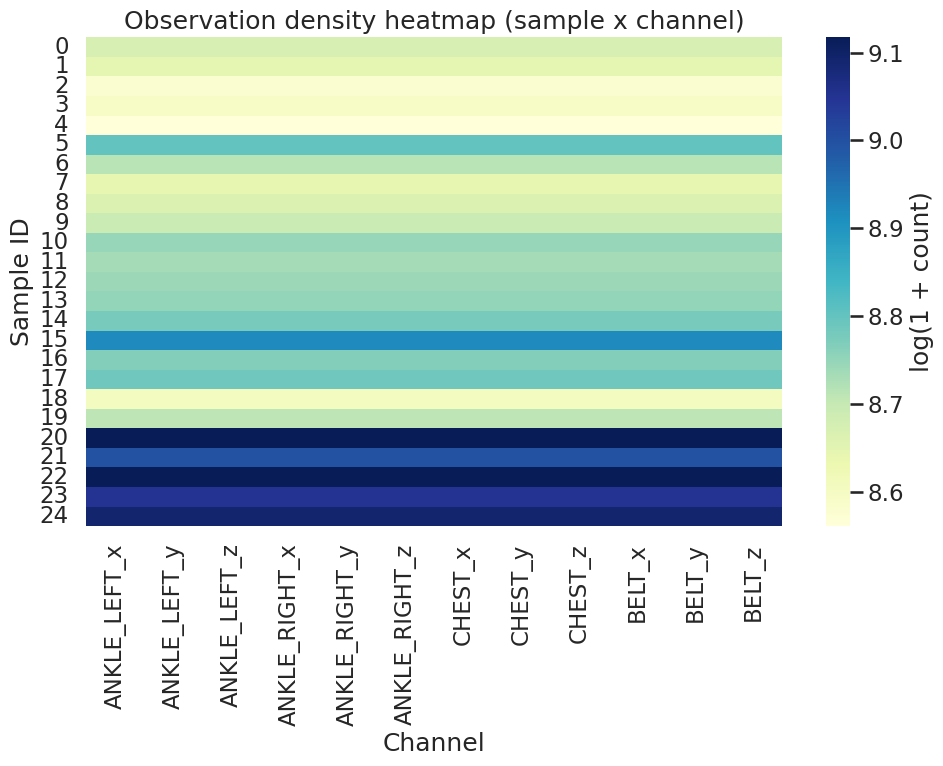

In [6]:
plot_channel_missingness(long_df, channel_names, n_samples=200)

## 5) 采样间隔分布

衡量不规则性：如果分布非常分散，说明采样时间并不均匀。

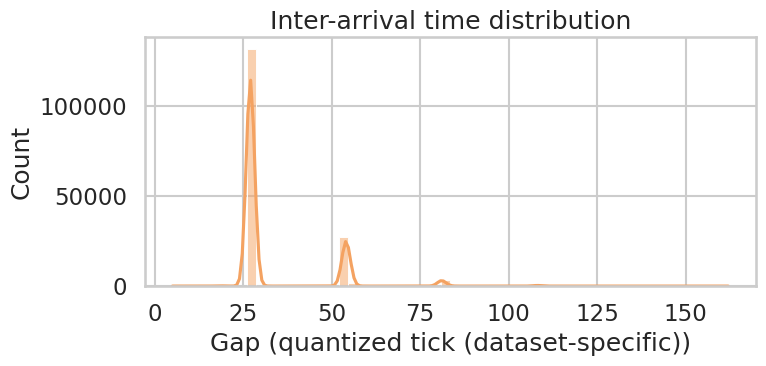

In [7]:
plot_interarrival_distribution(records, time_unit=time_unit)

## 6) 多变量时序轨迹（随机样本）

显示若干关键通道的多样本轨迹叠加。

In [8]:
preferred_channels = [
    'ANKLE_LEFT_x',
    'ANKLE_RIGHT_y',
    'CHEST_z',
    'BELT_x',
]

# 先与实际可用通道求交集，避免通道命名不一致导致空数据
channels_to_plot = [c for c in preferred_channels if c in long_df['channel'].astype(str).unique()]
if len(channels_to_plot) < 2:
    channels_to_plot = long_df['channel'].astype(str).value_counts().head(4).index.tolist()

channels_to_plot

['ANKLE_LEFT_x', 'ANKLE_RIGHT_y', 'CHEST_z', 'BELT_x']

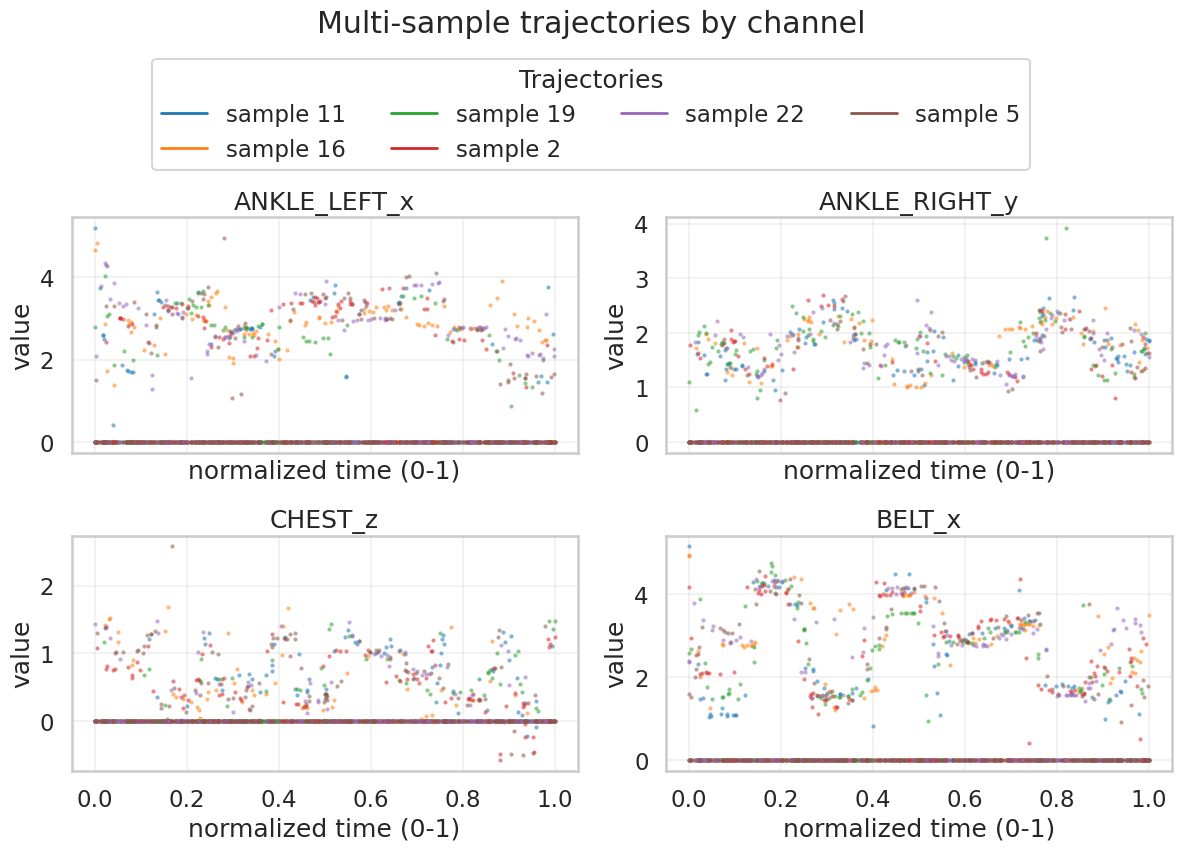

In [12]:
plot_multichannel_trajectories(
    long_df,
    channels=channels_to_plot,
    n_samples=6,
    max_points_per_sample=300,
    col_wrap=2,
    height=3.8,
    aspect=1.6,
    show_legend=True,
    plot_kind='scatter', # line or scatter
    normalize_time_per_sample=True,
)

读图说明：
- 每种颜色代表一个随机抽样到的样本（见顶部图例）。
- 每个子图是一个通道，横轴为样本内归一化时间（0-1），纵轴为该通道数值。
- 当前用散点而不是连线，避免不规则采样下“针状连线”造成视觉误导。
- 如果同一颜色在多个子图中同时出现模式突变，通常意味着该样本多部位动作同步变化。

## 7) 通道相关性

基于“每个样本每个通道的均值”估计变量之间的相关结构。

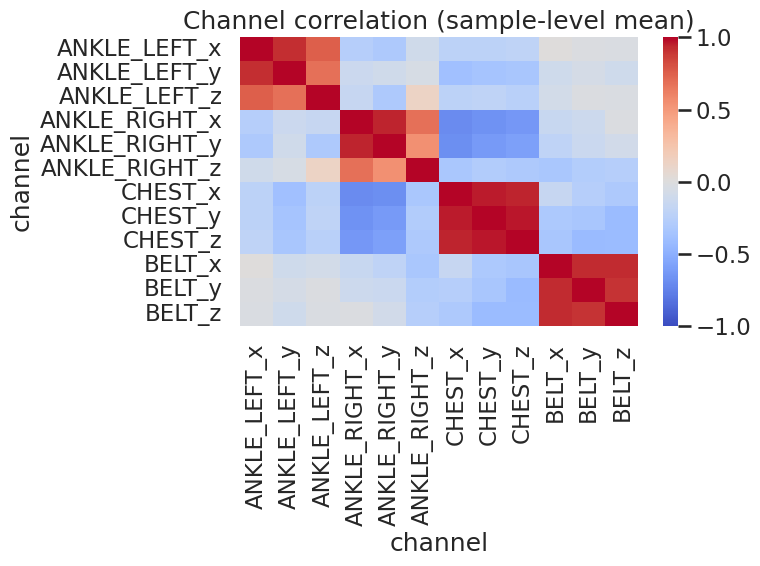

In [10]:
plot_channel_correlation(long_df, channel_names, max_samples=300)

## 8) 结论模板

你可以根据上面的图与统计，从以下角度总结：
1. 数据规模与稀疏程度：样本数、每样本观测数、时长分布
2. 不规则时间特征：时间间隔是否长尾、是否存在明显采样节律
3. 变量信息密度：哪些通道最稀疏、哪些最稳定
4. 变量联动关系：相关热图是否出现明显块状结构
5. 建模启发：是否适合 patch、插值、显式时间编码等策略
